In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score, classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False



In [75]:
import os
csv_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv') and 'country' in filename.lower():
            csv_path = os.path.join(dirname, filename)
            print('Found:', csv_path)

df = pd.read_csv(csv_path)
print('Shape:', df.shape)
df.head()

Found: /kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [76]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [77]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
child_mort,167.000000,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


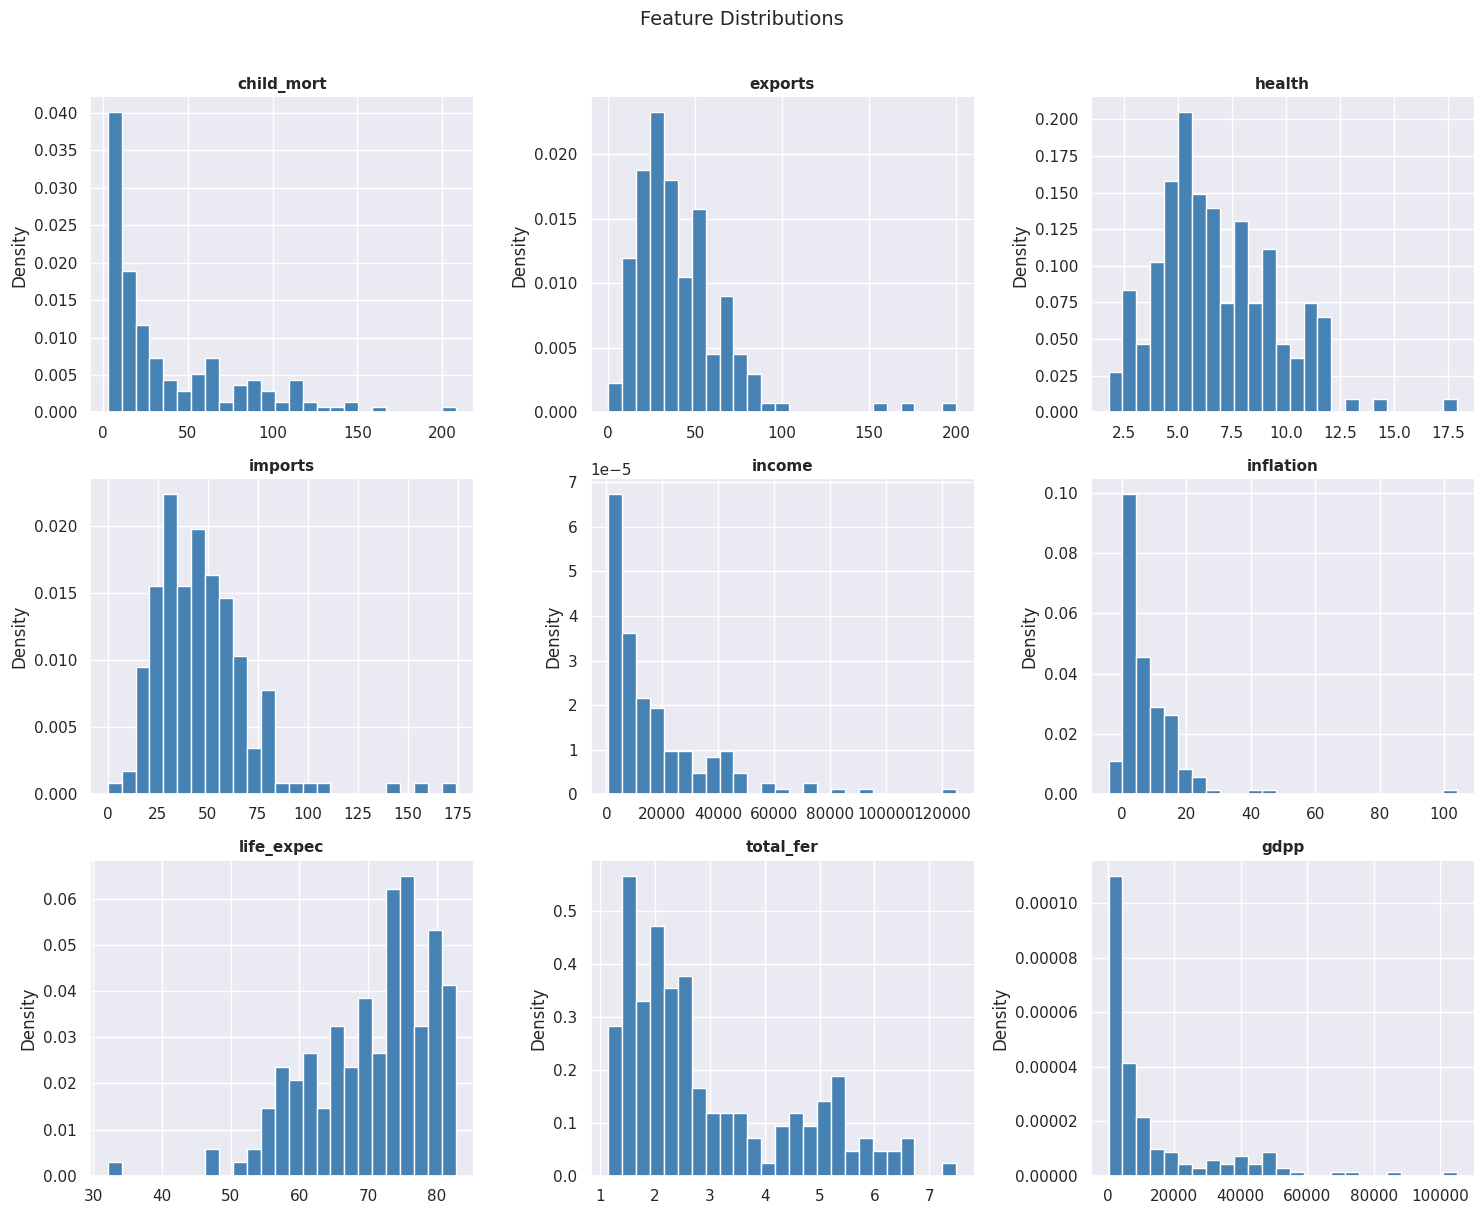

In [78]:
feat_cols = ['child_mort','exports','health','imports','income',
             'inflation','life_expec','total_fer','gdpp']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Density')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

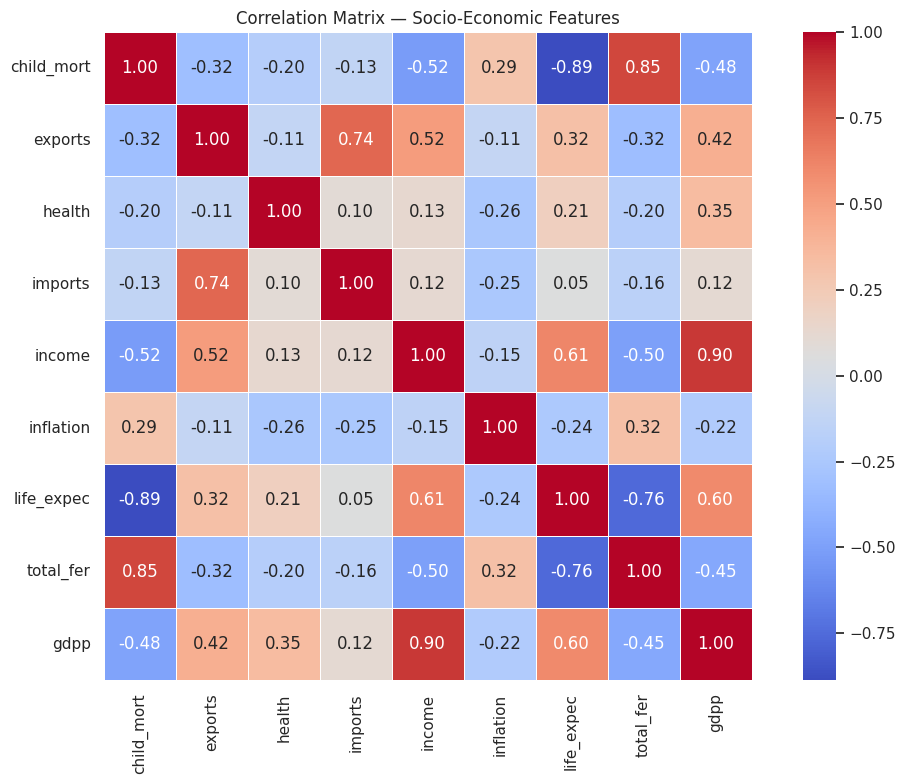

In [79]:
plt.figure(figsize=(11, 8))
sns.heatmap(df[feat_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Matrix — Socio-Economic Features')
plt.tight_layout()
plt.show()

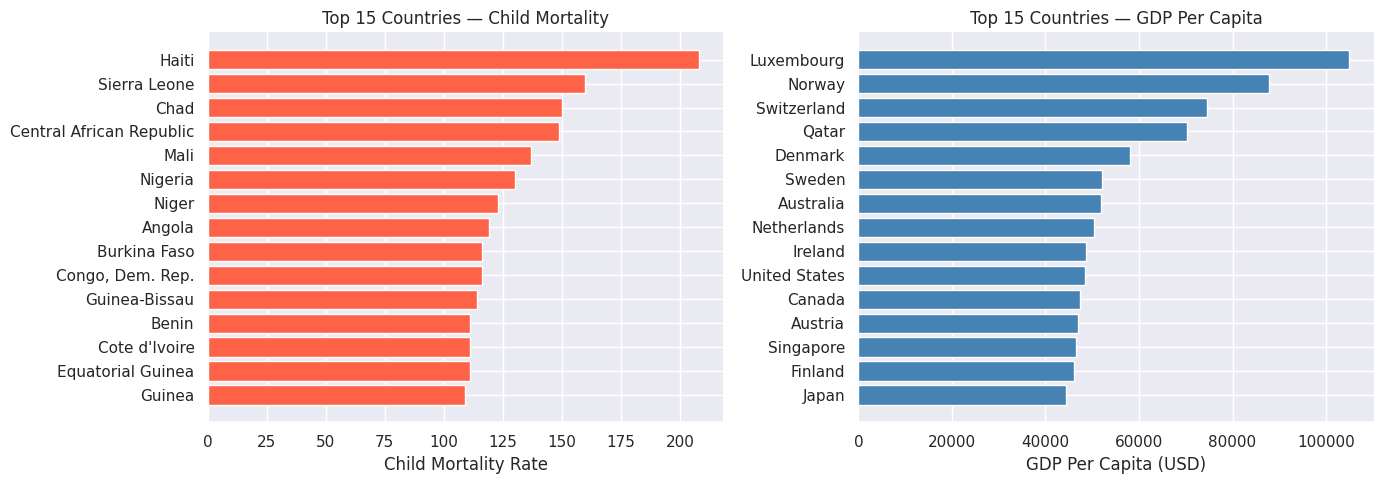

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_mort = df.nlargest(15, 'child_mort')
axes[0].barh(top_mort['country'], top_mort['child_mort'],
             color='tomato', edgecolor='white')
axes[0].set_title('Top 15 Countries — Child Mortality')
axes[0].set_xlabel('Child Mortality Rate')
axes[0].invert_yaxis()

top_gdp = df.nlargest(15, 'gdpp')
axes[1].barh(top_gdp['country'], top_gdp['gdpp'],
             color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Countries — GDP Per Capita')
axes[1].set_xlabel('GDP Per Capita (USD)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

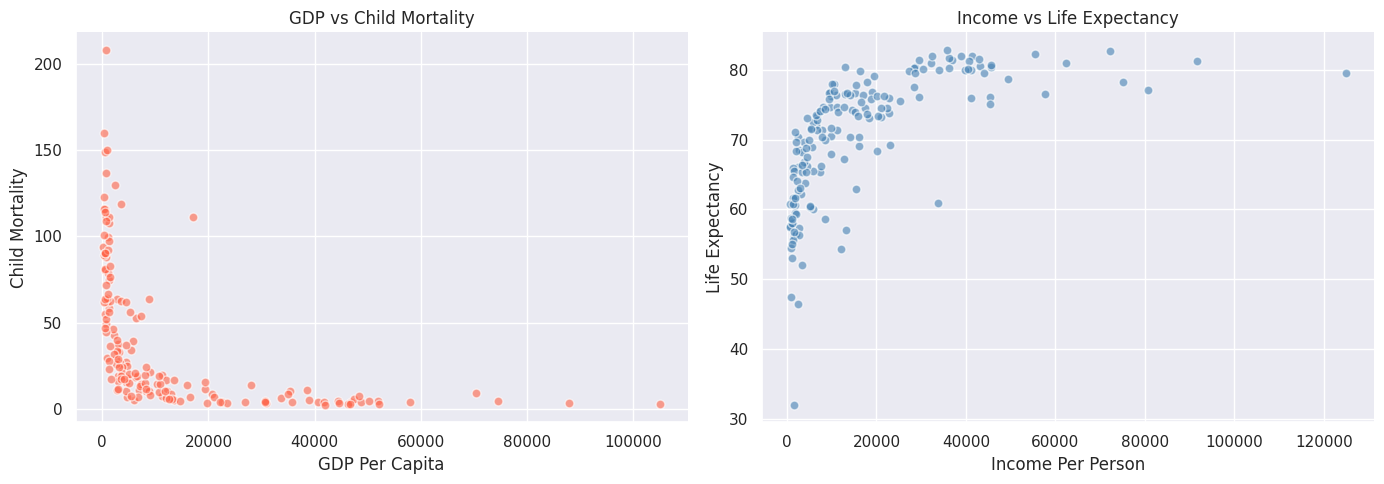

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['gdpp'], df['child_mort'],
                alpha=0.6, color='tomato', edgecolors='white', s=40)
axes[0].set_xlabel('GDP Per Capita')
axes[0].set_ylabel('Child Mortality')
axes[0].set_title('GDP vs Child Mortality')

axes[1].scatter(df['income'], df['life_expec'],
                alpha=0.6, color='steelblue', edgecolors='white', s=40)
axes[1].set_xlabel('Income Per Person')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('Income vs Life Expectancy')

plt.tight_layout()
plt.show()

In [82]:
X = df[feat_cols].copy()

sc   = StandardScaler()
X_sc = sc.fit_transform(X)
X_sc = pd.DataFrame(X_sc, columns=feat_cols, index=df.index)

print('Scaled shape:', X_sc.shape)
X_sc.describe().T.round(3)

Scaled shape: (167, 9)


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,-0.0,1.003,-0.887,-0.747,-0.472,0.593,4.221
exports,167.0,0.0,1.003,-1.500,-0.633,-0.224,0.375,5.814
health,167.0,0.0,1.003,-1.828,-0.692,-0.181,0.652,4.047
imports,167.0,0.0,1.003,-1.940,-0.691,-0.149,0.491,5.266
income,167.0,-0.0,1.003,-0.860,-0.717,-0.374,0.294,5.612
inflation,167.0,-0.0,1.003,-1.138,-0.567,-0.227,0.282,9.130
life_expec,167.0,0.0,1.003,-4.337,-0.593,0.287,0.704,1.381
total_fer,167.0,0.0,1.003,-1.191,-0.764,-0.356,0.618,3.009
gdpp,167.0,0.0,1.003,-0.697,-0.637,-0.454,0.059,5.037


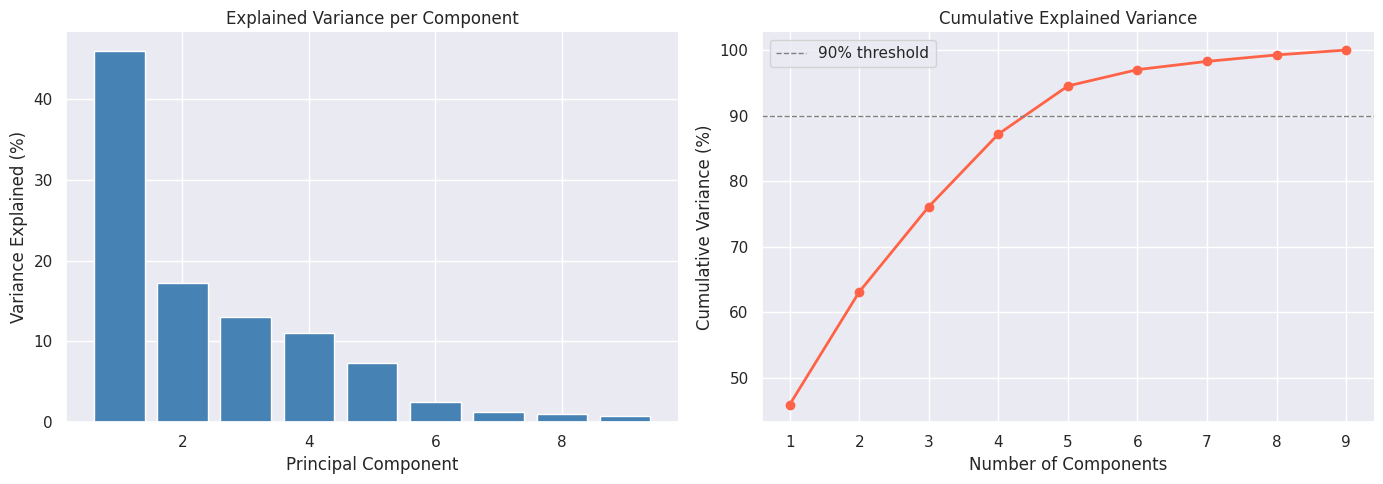

Components needed for 90% variance: 5


In [83]:
pca  = PCA(n_components=9)
pca.fit(X_sc)

exp_var  = pca.explained_variance_ratio_
cum_var  = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 10), exp_var * 100, color='steelblue', edgecolor='white')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')

axes[1].plot(range(1, 10), cum_var * 100, marker='o', color='tomato', lw=2)
axes[1].axhline(90, color='gray', ls='--', lw=1, label='90% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Components needed for 90% variance:',
      np.argmax(cum_var >= 0.90) + 1)

In [84]:
pca2  = PCA(n_components=2)
X_pca = pca2.fit_transform(X_sc)
print(f'PCA 2D explains: {pca2.explained_variance_ratio_.sum()*100:.1f}% variance')

PCA 2D explains: 63.1% variance


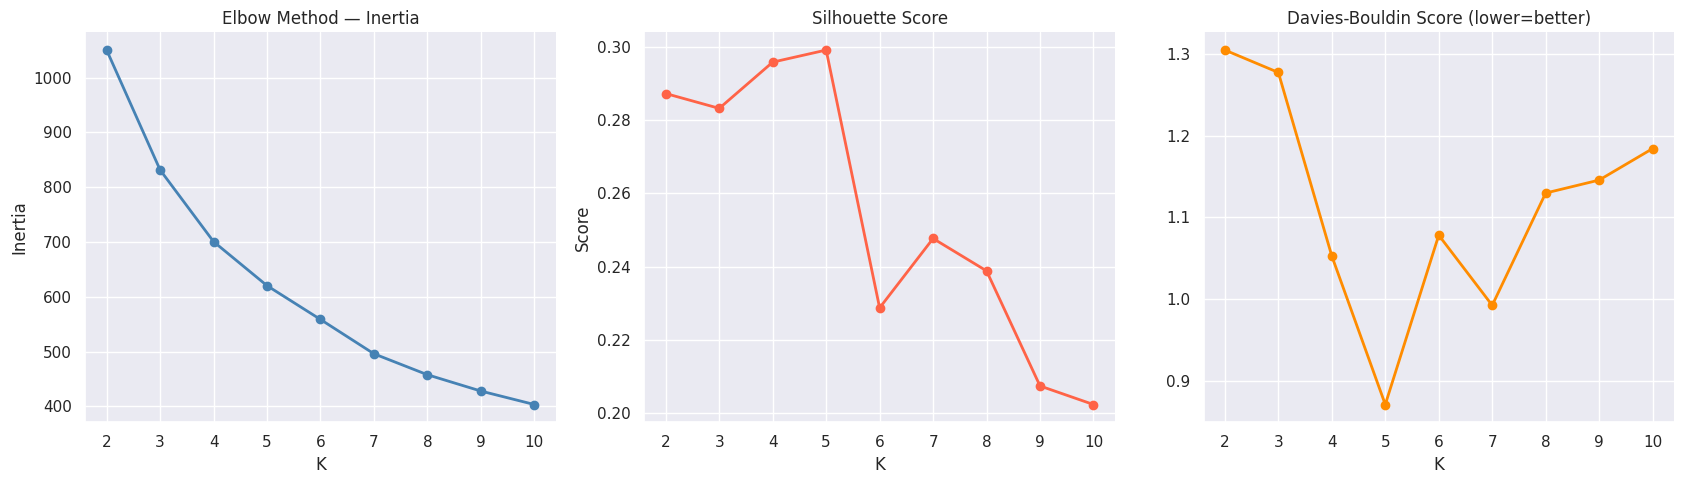

Best K (max Silhouette): 5  |  Score: 0.2993


In [85]:
inertias, sil_scores, db_scores = [], [], []
K = range(2, 11)

for k in K:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sc, lbl))
    db_scores.append(davies_bouldin_score(X_sc, lbl))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(K, inertias,   marker='o', color='steelblue', lw=2)
axes[0].set_title('Elbow Method — Inertia')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(K, sil_scores, marker='o', color='tomato',    lw=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')

axes[2].plot(K, db_scores,  marker='o', color='darkorange', lw=2)
axes[2].set_title('Davies-Bouldin Score (lower=better)')
axes[2].set_xlabel('K')

plt.tight_layout()
plt.show()

best_k = K[np.argmax(sil_scores)]
print(f'Best K (max Silhouette): {best_k}  |  Score: {max(sil_scores):.4f}')

In [86]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = km_final.fit_predict(X_sc)

sil  = silhouette_score(X_sc, df['kmeans_cluster'])
dbi  = davies_bouldin_score(X_sc, df['kmeans_cluster'])
print(f'K-Means (k=3) — Silhouette: {sil:.4f}  |  DBI: {dbi:.4f}')
print('\nCluster sizes:')
print(df['kmeans_cluster'].value_counts().sort_index())

K-Means (k=3) — Silhouette: 0.2833  |  DBI: 1.2769

Cluster sizes:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


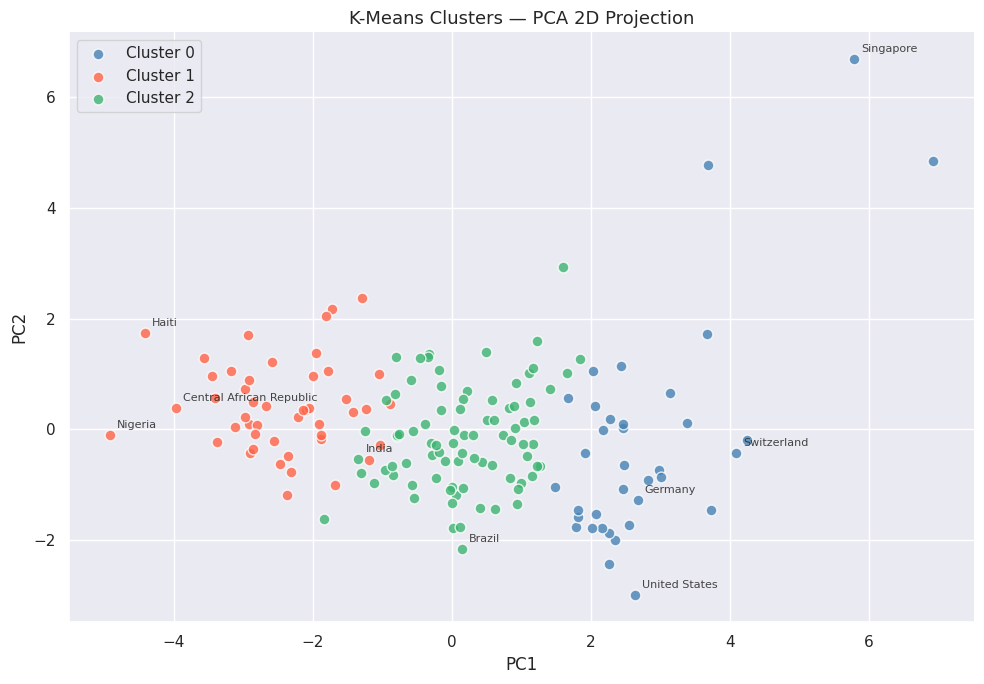

In [87]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue','tomato','mediumseagreen']
labels = ['Cluster 0','Cluster 1','Cluster 2']

for c in range(3):
    mask = df['kmeans_cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[c], label=labels[c],
               alpha=0.8, edgecolors='white', s=60)

for i, row in df.iterrows():
    if row['country'] in ['Haiti','Central African Republic',
                          'United States','Germany','Switzerland','Singapore',
                          'India','Nigeria','Brazil']:
        ax.annotate(row['country'],
                    (X_pca[i, 0], X_pca[i, 1]),
                    fontsize=8, alpha=0.85,
                    xytext=(5, 5), textcoords='offset points')

ax.set_title('K-Means Clusters — PCA 2D Projection', fontsize=13)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

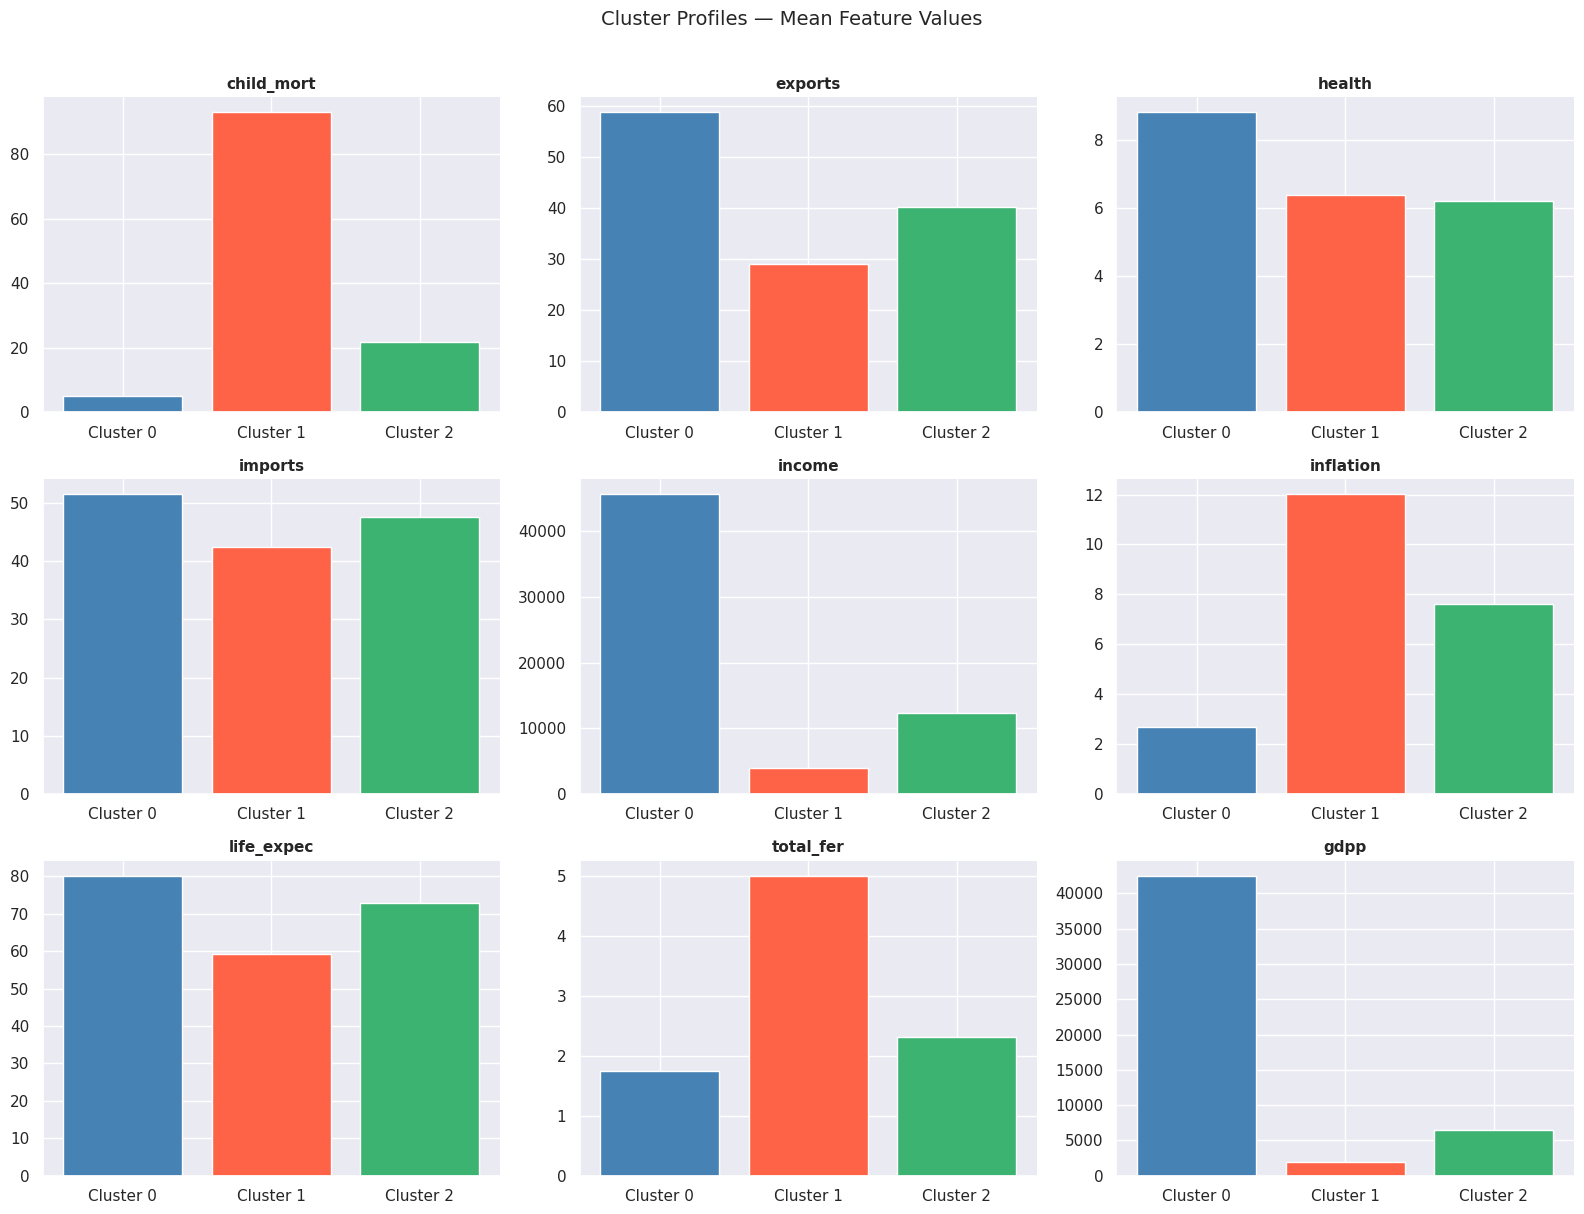


Cluster Profile:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [88]:
cluster_profile = df.groupby('kmeans_cluster')[feat_cols].mean().round(2)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    axes[i].bar(['Cluster 0','Cluster 1','Cluster 2'],
                cluster_profile[col],
                color=['steelblue','tomato','mediumseagreen'],
                edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
plt.suptitle('Cluster Profiles — Mean Feature Values', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nCluster Profile:')
display(cluster_profile)

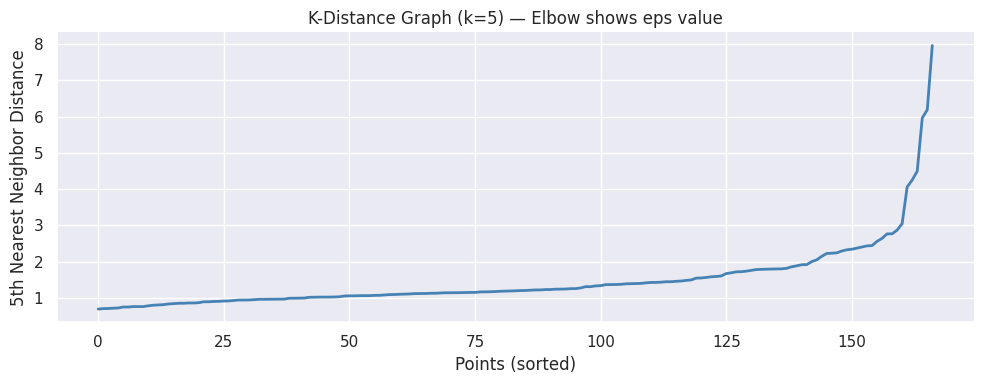

In [89]:
from sklearn.neighbors import NearestNeighbors

nn   = NearestNeighbors(n_neighbors=5)
nn.fit(X_sc)
dist, _ = nn.kneighbors(X_sc)
k_dist  = np.sort(dist[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color='steelblue', lw=2)
ax.set_title('K-Distance Graph (k=5) — Elbow shows eps value')
ax.set_xlabel('Points (sorted)'); ax.set_ylabel('5th Nearest Neighbor Distance')
plt.tight_layout()
plt.show()

In [90]:
db  = DBSCAN(eps=2.5, min_samples=5)
df['dbscan_cluster'] = db.fit_predict(X_sc)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise    = (df['dbscan_cluster'] == -1).sum()

print(f'DBSCAN Clusters found : {n_clusters}')
print(f'Noise points (-1)     : {n_noise}')
print('\nCluster distribution:')
print(df['dbscan_cluster'].value_counts())

if n_clusters > 1:
    mask  = df['dbscan_cluster'] != -1
    sil_d = silhouette_score(X_sc[mask], df['dbscan_cluster'][mask])
    print(f'\nSilhouette Score (excl. noise): {sil_d:.4f}')

DBSCAN Clusters found : 1
Noise points (-1)     : 6

Cluster distribution:
dbscan_cluster
 0    161
-1      6
Name: count, dtype: int64


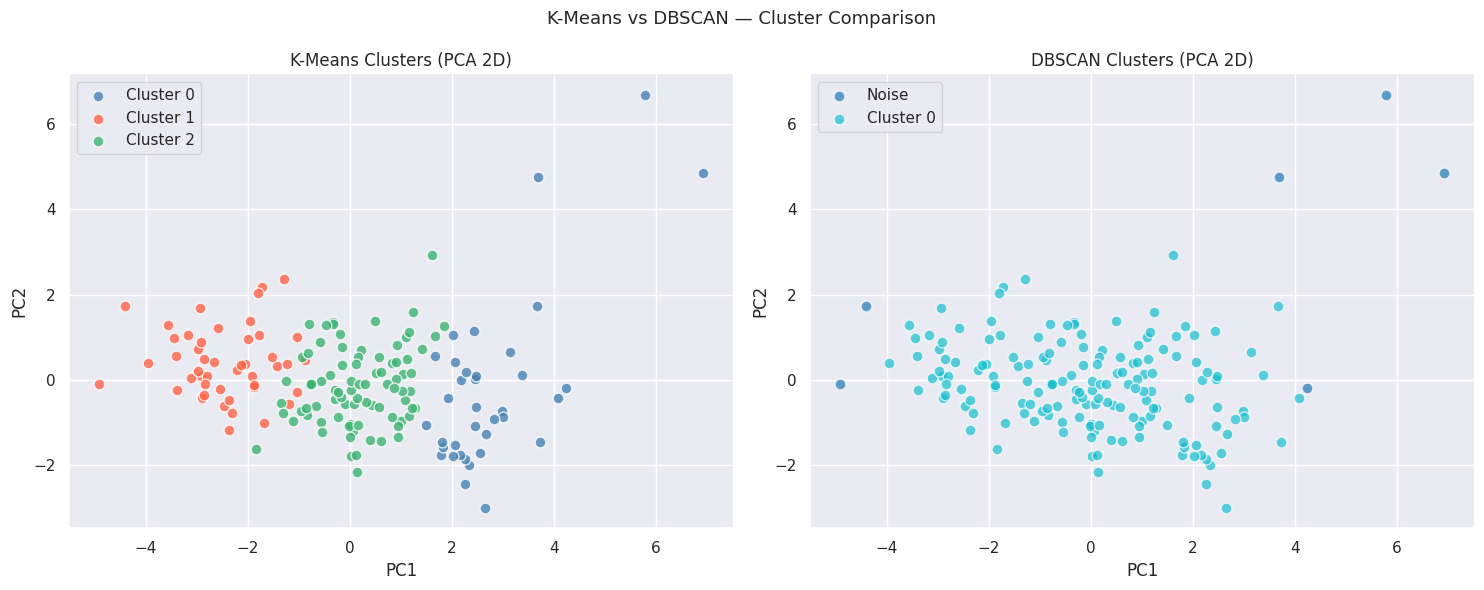

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for c in range(3):
    mask = df['kmeans_cluster'] == c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1],
                    c=colors[c], label=f'Cluster {c}',
                    alpha=0.8, edgecolors='white', s=60)
axes[0].set_title('K-Means Clusters (PCA 2D)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

db_labels = df['dbscan_cluster'].values
unique_db  = sorted(set(db_labels))
cmap_db    = plt.cm.get_cmap('tab10', len(unique_db))
for idx, c in enumerate(unique_db):
    mask = db_labels == c
    lbl  = f'Noise' if c == -1 else f'Cluster {c}'
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1],
                    c=[cmap_db(idx)], label=lbl,
                    alpha=0.7, edgecolors='white', s=60)
axes[1].set_title('DBSCAN Clusters (PCA 2D)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('K-Means vs DBSCAN — Cluster Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [92]:
cluster_names = {0: 'Developing', 1: 'Developed', 2: 'Underdeveloped'}
profile = df.groupby('kmeans_cluster')[['child_mort','gdpp','income','life_expec']].mean()

for k, name in cluster_names.items():
    row = profile.loc[k]
    print(f'Cluster {k} → {name}:  child_mort={row.child_mort:.1f}, '
          f'gdpp={row.gdpp:.0f}, income={row.income:.0f}, life_expec={row.life_expec:.1f}')

Cluster 0 → Developing:  child_mort=5.0, gdpp=42494, income=45672, life_expec=80.1
Cluster 1 → Developed:  child_mort=93.0, gdpp=1922, income=3942, life_expec=59.2
Cluster 2 → Underdeveloped:  child_mort=21.9, gdpp=6486, income=12306, life_expec=72.8


In [93]:
target = 'kmeans_cluster'
X_cls  = X_sc.copy()
y_cls  = df[target].copy()

X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls,
                                            test_size=0.2,
                                            random_state=42,
                                            stratify=y_cls)
print(f'Train: {X_tr.shape}  |  Test: {X_te.shape}')
print('Class distribution (train):', dict(y_tr.value_counts().sort_index()))

Train: (133, 9)  |  Test: (34, 9)
Class distribution (train): {0: np.int64(29), 1: np.int64(37), 2: np.int64(67)}


In [94]:
def eval_clf(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    p   = model.predict(Xte)
    acc = accuracy_score(yte, p)
    cv  = cross_val_score(model, Xtr, ytr, cv=5, scoring='accuracy').mean()
    return {'Model': name, 'Accuracy': round(acc,4), 'CV Accuracy': round(cv,4),
            'model_obj': model, 'preds': p}

clfs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'SVM'                 : SVC(kernel='rbf', random_state=42),
}

clf_results = [eval_clf(n, m, X_tr, y_tr, X_te, y_te) for n, m in clfs.items()]
clf_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['model_obj','preds']}
                        for r in clf_results]).set_index('Model')
clf_df.sort_values('Accuracy', ascending=False).style.background_gradient(cmap='Greens')

,Accuracy,CV Accuracy
Model,,
Logistic Regression,1.000000,0.939900
SVM,0.970600,0.939900
Decision Tree,0.941200,0.909700


Best Classifier: Logistic Regression

Classification Report:
                precision    recall  f1-score   support

    Developing       1.00      1.00      1.00         7
     Developed       1.00      1.00      1.00        10
Underdeveloped       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



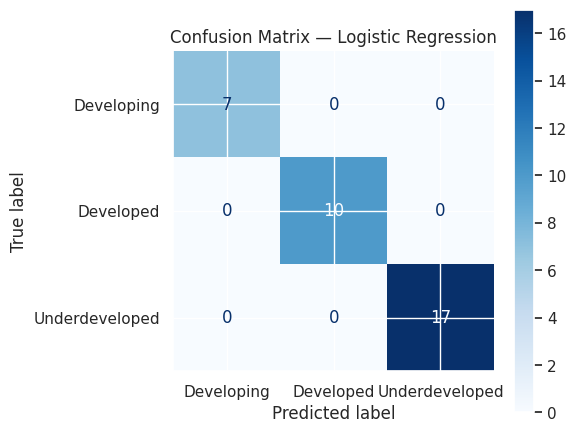

In [95]:
best_clf_name = clf_df['Accuracy'].idxmax()
best_clf_obj  = next(r['model_obj'] for r in clf_results if r['Model'] == best_clf_name)
best_clf_pred = next(r['preds']     for r in clf_results if r['Model'] == best_clf_name)

print(f'Best Classifier: {best_clf_name}')
print('\nClassification Report:')
print(classification_report(y_te, best_clf_pred,
                             target_names=['Developing','Developed','Underdeveloped']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_te, best_clf_pred,
    display_labels=['Developing','Developed','Underdeveloped'],
    cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_clf_name}')
plt.tight_layout()
plt.show()

In [96]:
ens_models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
}

ens_results = [eval_clf(n, m, X_tr, y_tr, X_te, y_te) for n, m in ens_models.items()]
ens_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['model_obj','preds']}
                        for r in ens_results]).set_index('Model')
ens_df.sort_values('Accuracy', ascending=False).style.background_gradient(cmap='Oranges')

,Accuracy,CV Accuracy
Model,,
Random Forest,1.000000,0.931900
Gradient Boosting,0.970600,0.887200
XGBoost,0.941200,0.931900


Best Ensemble: Random Forest

Classification Report:
                precision    recall  f1-score   support

    Developing       1.00      1.00      1.00         7
     Developed       1.00      1.00      1.00        10
Underdeveloped       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



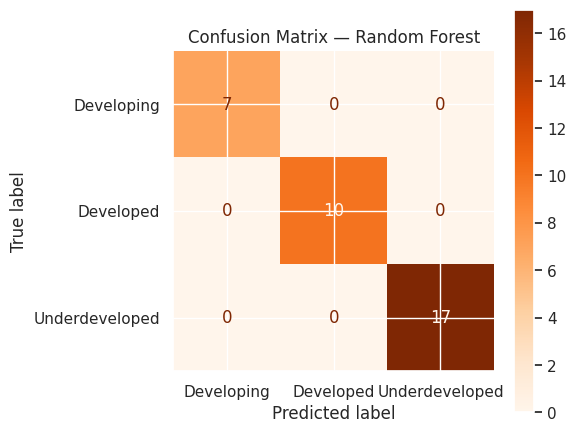

In [97]:
best_ens_name = ens_df['Accuracy'].idxmax()
best_ens_obj  = next(r['model_obj'] for r in ens_results if r['Model'] == best_ens_name)
best_ens_pred = next(r['preds']     for r in ens_results if r['Model'] == best_ens_name)

print(f'Best Ensemble: {best_ens_name}')
print('\nClassification Report:')
print(classification_report(y_te, best_ens_pred,
                             target_names=['Developing','Developed','Underdeveloped']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_te, best_ens_pred,
    display_labels=['Developing','Developed','Underdeveloped'],
    cmap='Oranges', ax=ax)
ax.set_title(f'Confusion Matrix — {best_ens_name}')
plt.tight_layout()
plt.show()

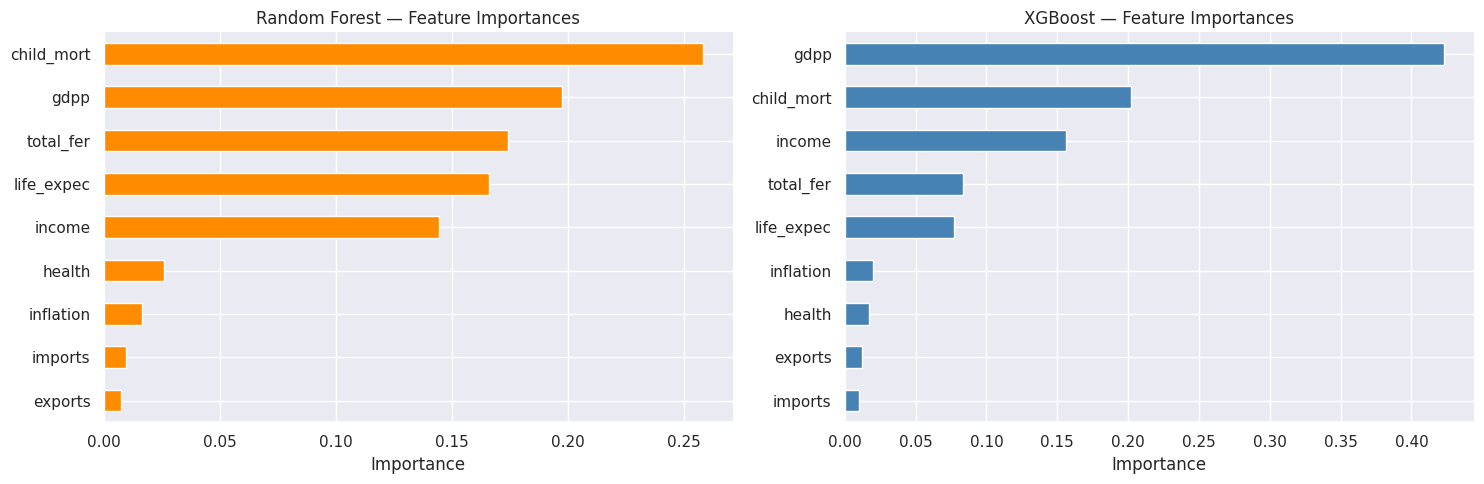

In [98]:
rf_obj  = next(r['model_obj'] for r in ens_results if r['Model'] == 'Random Forest')
xgb_obj = next(r['model_obj'] for r in ens_results if r['Model'] == 'XGBoost')

feat_imp_rf  = pd.Series(rf_obj.feature_importances_,  index=feat_cols)
feat_imp_xgb = pd.Series(xgb_obj.feature_importances_, index=feat_cols)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

feat_imp_rf.sort_values().plot(kind='barh', ax=axes[0],
                                color='darkorange', edgecolor='white')
axes[0].set_title('Random Forest — Feature Importances')
axes[0].set_xlabel('Importance')

feat_imp_xgb.sort_values().plot(kind='barh', ax=axes[1],
                                 color='steelblue', edgecolor='white')
axes[1].set_title('XGBoost — Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [99]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

gs = GridSearchCV(RandomForestClassifier(random_state=42),
                  param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
gs.fit(X_tr, y_tr)

print('Best params:', gs.best_params_)
print(f'Best CV Accuracy: {gs.best_score_:.4f}')

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}
Best CV Accuracy: 0.9473


In [100]:
best_rf_tuned = gs.best_estimator_
p_tuned       = best_rf_tuned.predict(X_te)

print(f'Tuned RF Accuracy: {accuracy_score(y_te, p_tuned):.4f}')
print('\nClassification Report:')
print(classification_report(y_te, p_tuned,
                             target_names=['Developing','Developed','Underdeveloped']))

Tuned RF Accuracy: 1.0000

Classification Report:
                precision    recall  f1-score   support

    Developing       1.00      1.00      1.00         7
     Developed       1.00      1.00      1.00        10
Underdeveloped       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



In [101]:
voter = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(**gs.best_params_, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='mlogloss', verbosity=0)),
], voting='hard')

voter.fit(X_tr, y_tr)
p_voter = voter.predict(X_te)

print(f'Voting Classifier Accuracy: {accuracy_score(y_te, p_voter):.4f}')
print('\nClassification Report:')
print(classification_report(y_te, p_voter,
                             target_names=['Developing','Developed','Underdeveloped']))

Voting Classifier Accuracy: 1.0000

Classification Report:
                precision    recall  f1-score   support

    Developing       1.00      1.00      1.00         7
     Developed       1.00      1.00      1.00        10
Underdeveloped       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



Logistic Regression    1.000000
Random Forest          1.000000
RF (Tuned)             1.000000
Voting Classifier      1.000000
Gradient Boosting      0.970588
SVM                    0.970588
Decision Tree          0.941176
XGBoost                0.941176


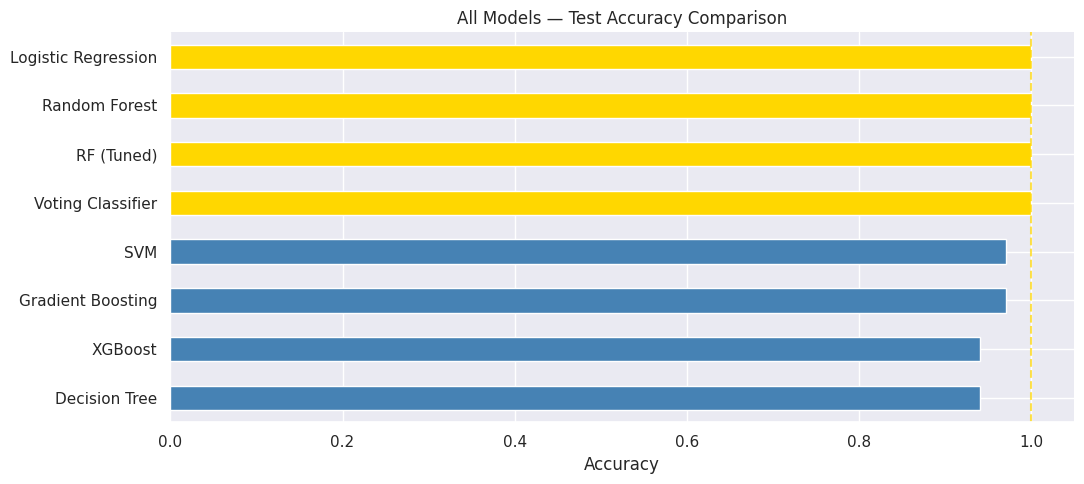

In [102]:
all_models = {}
for r in clf_results + ens_results:
    all_models[r['Model']] = accuracy_score(y_te, r['preds'])
all_models['RF (Tuned)']       = accuracy_score(y_te, p_tuned)
all_models['Voting Classifier'] = accuracy_score(y_te, p_voter)

comp = pd.Series(all_models).sort_values(ascending=False)
print(comp.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
colors_bar = ['gold' if v == comp.max() else 'steelblue' for v in comp.values]
comp.sort_values().plot(kind='barh', ax=ax, color=colors_bar[::-1], edgecolor='white')
ax.axvline(comp.max(), color='gold', ls='--', lw=1.5, alpha=0.7)
ax.set_title('All Models — Test Accuracy Comparison')
ax.set_xlabel('Accuracy')
plt.tight_layout()
plt.show()

In [103]:
label_map = {0: 'Developing', 1: 'Developed', 2: 'Underdeveloped'}
df['segment'] = df['kmeans_cluster'].map(label_map)

for seg in ['Underdeveloped', 'Developing', 'Developed']:
    grp = df[df['segment'] == seg]['country'].tolist()
    print(f'\n {seg} ({len(grp)} countries):')
    print(', '.join(sorted(grp)))


 Underdeveloped (84 countries):
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China, Colombia, Costa Rica, Croatia, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Fiji, Georgia, Grenada, Guatemala, Guyana, Hungary, India, Indonesia, Iran, Jamaica, Jordan, Kazakhstan, Kyrgyz Republic, Latvia, Lebanon, Libya, Lithuania, Macedonia, FYR, Malaysia, Maldives, Mauritius, Micronesia, Fed. Sts., Moldova, Mongolia, Montenegro, Morocco, Myanmar, Nepal, Oman, Panama, Paraguay, Peru, Philippines, Poland, Romania, Russia, Samoa, Saudi Arabia, Serbia, Seychelles, Solomon Islands, Sri Lanka, St. Vincent and the Grenadines, Suriname, Tajikistan, Thailand, Tonga, Tunisia, Turkey, Turkmenistan, Ukraine, Uruguay, Uzbekistan, Vanuatu, Venezuela, Vietnam

 Developing (36 countries):
Australia, Austria, Bahrain, Belgium, Brunei, Canada, C

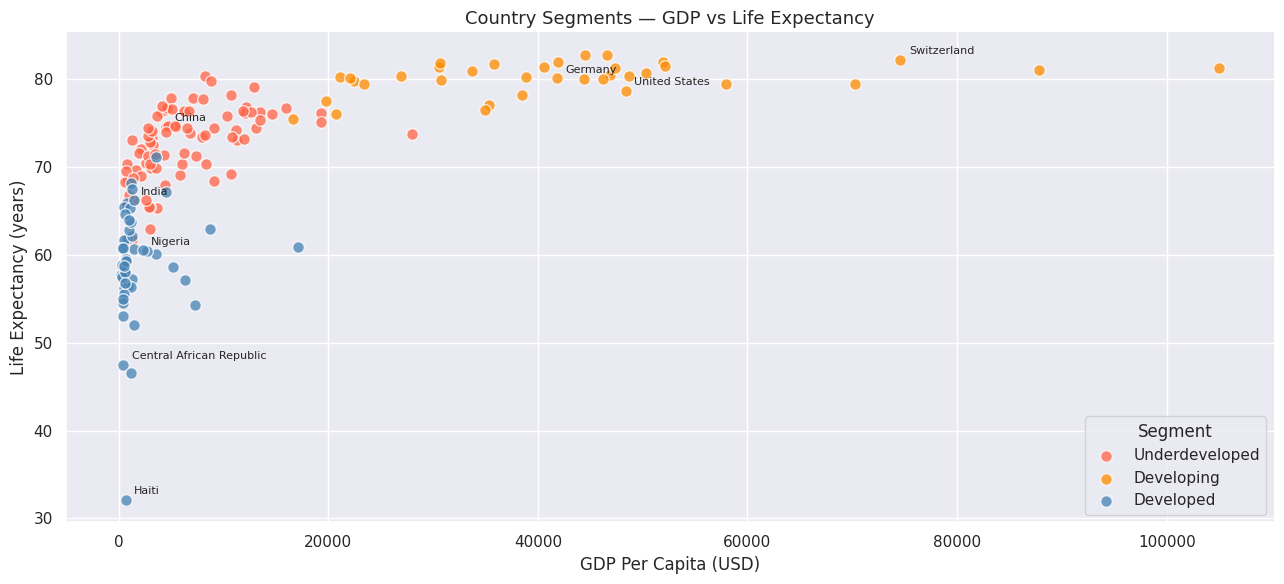

In [104]:
fig, ax = plt.subplots(figsize=(13, 6))
seg_colors = {'Underdeveloped':'tomato','Developing':'darkorange','Developed':'steelblue'}

for seg, color in seg_colors.items():
    mask = df['segment'] == seg
    ax.scatter(df.loc[mask,'gdpp'], df.loc[mask,'life_expec'],
               c=color, label=seg, alpha=0.75, edgecolors='white', s=70)

for _, row in df[df['country'].isin(['United States','Germany','Haiti',
                                      'Central African Republic',
                                      'India','China','Nigeria','Switzerland'])].iterrows():
    ax.annotate(row['country'], (row['gdpp'], row['life_expec']),
                fontsize=8, xytext=(6,4), textcoords='offset points')

ax.set_xlabel('GDP Per Capita (USD)');  ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Country Segments — GDP vs Life Expectancy', fontsize=13)
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

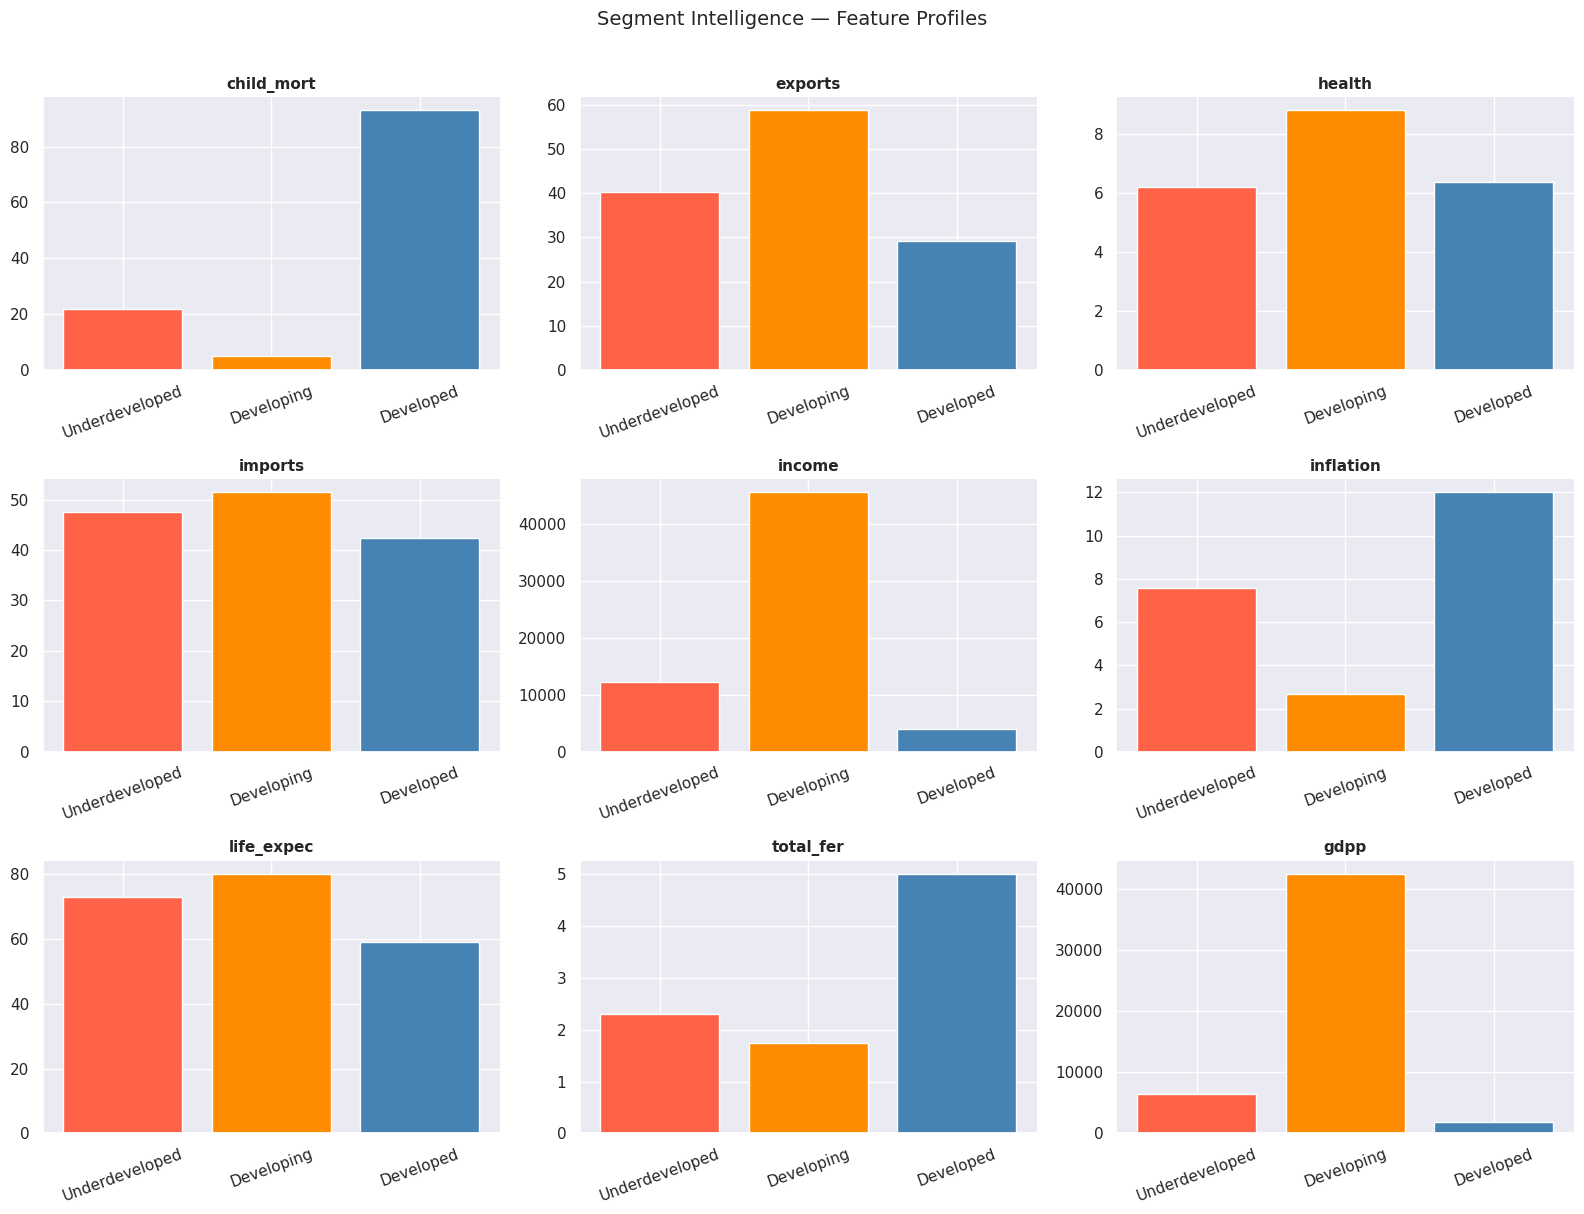

In [105]:
seg_stats = df.groupby('segment')[feat_cols].mean().round(2)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
seg_col = ['tomato','darkorange','steelblue']

for i, col in enumerate(feat_cols):
    vals = [seg_stats.loc[s, col] if s in seg_stats.index else 0
            for s in ['Underdeveloped','Developing','Developed']]
    axes[i].bar(['Underdeveloped','Developing','Developed'],
                vals, color=seg_col, edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Segment Intelligence — Feature Profiles', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [106]:
print('='*55)
print('      CUSTOMER INTELLIGENCE SYSTEM — SUMMARY')
print('='*55)
print(f'\nDataset : 167 countries × 9 socio-economic features')
print(f'\n--- CLUSTERING ---')
km3 = silhouette_score(X_sc, df['kmeans_cluster'])
print(f'K-Means  (k=3) Silhouette Score : {km3:.4f}')
db_mask = df['dbscan_cluster'] != -1
if db_mask.sum() > 1 and len(df.loc[db_mask,'dbscan_cluster'].unique()) > 1:
    sil_db = silhouette_score(X_sc[db_mask], df.loc[db_mask,'dbscan_cluster'])
    print(f'DBSCAN         Silhouette Score : {sil_db:.4f}')

print(f'\n--- CLASSIFICATION ---')
for r in clf_results:
    print(f'{r["Model"]:22s}: {r["Accuracy"]:.4f}')

print(f'\n--- ENSEMBLE LEARNING ---')
for r in ens_results:
    print(f'{r["Model"]:22s}: {accuracy_score(y_te, r["preds"]):.4f}')
print(f'{"RF (Tuned)":22s}: {accuracy_score(y_te, p_tuned):.4f}')
print(f'{"Voting Classifier":22s}: {accuracy_score(y_te, p_voter):.4f}')
print('='*55)

      CUSTOMER INTELLIGENCE SYSTEM — SUMMARY

Dataset : 167 countries × 9 socio-economic features

--- CLUSTERING ---
K-Means  (k=3) Silhouette Score : 0.2833

--- CLASSIFICATION ---
Logistic Regression   : 1.0000
Decision Tree         : 0.9412
SVM                   : 0.9706

--- ENSEMBLE LEARNING ---
Random Forest         : 1.0000
Gradient Boosting     : 0.9706
XGBoost               : 0.9412
RF (Tuned)            : 1.0000
Voting Classifier     : 1.0000
